# Data Science Lab Winter Project 2024/2025
## Age Detection
Within the field of speech processing, a long-standing task of interest is estimating the age of a speaker based on their vocal characteristics. Some systems are capable of analyzing spoken sentences to extract features that correlate with the speaker’s age. The process of estimating a speaker’s age from their speech is referred to as age estimation. The target (output) of the system is a single value representing the estimated age of the speaker.

Report by:
- Gosmar Dario: s337625
- Maretto Chiara: s339401

# 1 Imports
## 1.1 Library Import

In [1]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
from scipy.io import wavfile
import librosa

## 1.2 Dataset Import
The dataset is comprised of 3,624 samples: 2,933 samples for the **development set** and 691 samples for the **evaluation set**. Each sample corresponds to a spoken sentence, and the associated speaker’s age is provided as the target label. 
The speech samples have been collected in controlled conditions to ensure consistent feature extraction.

For each sample, a variety of acoustic and linguistic features have been extracted from the speech signal. These features form the dataset and include:
- **sampling rate**: the sampling rate of the audio signal, in Hz
- **age**: the chronological age of the speaker (target label)
- **gender**: the gender of the speake
- **ethnicity**: the ethnicity of the speaker
- **mean pitch**, **max pitch**, **min pitch**: mean, maximum, and minimum pitch of the speech signal, in Hz
- **jitter**: a measure of the variations in pitch, representing voice stability
- **shimmer**: a measure of amplitude variations in the speech signal
- **energy**: the overall energy of the speech signal
- **zcr mean**: the mean zero-crossing rate, indicating the number of times the signal changes sign
- **spectral centroid mean**: the mean spectral centroid, representing the “center of mass” of the frequency spectrum
- **tempo**: the estimated speaking rate, in beats per minute (BPM)
- **hnr**: the harmonic-to-noise ratio, indicating voice quality
- **num words**, **num characters**: the number of words and characters in the spoken sentence
- **num pauses**: the number of pauses detected in the speech
- **silence duration**: the total duration of silence within the speech signal, in seconds
- **path**: the file path to the audio recording

In [2]:
dev_df = pd.read_csv("DSL_Winter_Project_2025/development.csv")
eval_df = pd.read_csv("DSL_Winter_Project_2025/evaluation.csv")

# 2 Data Exploration

In [3]:
dev_df.info(), dev_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2933 entries, 0 to 2932
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Id                      2933 non-null   int64  
 1   sampling_rate           2933 non-null   int64  
 2   age                     2933 non-null   float64
 3   gender                  2933 non-null   object 
 4   ethnicity               2933 non-null   object 
 5   mean_pitch              2933 non-null   float64
 6   max_pitch               2933 non-null   float64
 7   min_pitch               2933 non-null   float64
 8   jitter                  2933 non-null   float64
 9   shimmer                 2933 non-null   float64
 10  energy                  2933 non-null   float64
 11  zcr_mean                2933 non-null   float64
 12  spectral_centroid_mean  2933 non-null   float64
 13  tempo                   2933 non-null   object 
 14  hnr                     2933 non-null   

(None, (2933, 20))

In [4]:
def get_duration(row):
    directory = 'DSL_Winter_Project_2025/'
    file_path = os.path.join(directory, row['path'])
    if os.path.isfile(file_path):
        y, sr = librosa.load(file_path, sr=row['sampling_rate'])
        return librosa.get_duration(y=y, sr=sr)
    return np.nan

In [5]:
data_list = []
spectograms = []
durations = []

dev_df['duration'] = dev_df.apply(get_duration, axis=1)
eval_df['duration'] = eval_df.apply(get_duration, axis=1)

In [6]:
# define a copy of the df to work on
df = dev_df.copy() 

In [7]:
df['tempo'] = df['tempo'].str.replace('[', '').str.replace(']', '').astype('float')
eval_df['tempo'] = eval_df['tempo'].str.replace('[', '').str.replace(']', '').astype('float')
df['tempo']

0       151.999081
1       129.199219
2       117.453835
3       117.453835
4       112.347147
           ...    
2928    184.570312
2929     83.354335
2930     89.102909
2931    143.554688
2932     83.354335
Name: tempo, Length: 2933, dtype: float64

In [8]:
df.describe()

,Id,sampling_rate,age,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,duration
count,2933.000000,2933.0,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000
mean,1466.000000,22050.0,27.897886,1189.536569,3779.570485,146.934930,0.021190,0.107741,0.005208,0.104774,2176.369847,125.085771,-74.526288,41.307535,167.936243,12.423116,13.501159,16.623614
std,846.828495,0.0,13.093316,414.193673,532.847869,3.757917,0.006626,0.029005,0.006074,0.051646,578.925294,33.812698,38.446856,32.782431,133.816974,14.273205,10.839142,13.935071
min,0.000000,22050.0,6.000000,346.974330,935.515560,145.349140,0.007292,0.045205,0.000028,0.015947,692.116731,51.679688,-193.693345,0.000000,0.000000,1.000000,0.668345,0.668345
25%,733.000000,22050.0,19.000000,818.922360,3948.234400,145.419140,0.016734,0.087378,0.001960,0.060733,1740.756716,103.359375,-104.555692,4.000000,14.000000,1.000000,1.732925,1.783401
50%,1466.000000,22050.0,23.000000,1208.998300,3998.397200,145.622010,0.020525,0.104697,0.003716,0.098964,2150.814043,117.453835,-84.415550,69.000000,281.000000,8.000000,17.368526,20.749297
75%,2199.000000,22050.0,32.000000,1523.777700,3999.485400,146.820890,0.024558,0.124993,0.006338,0.139559,2566.190670,143.554688,-40.339359,69.000000,281.000000,20.000000,21.408798,26.281769
max,2932.000000,22050.0,97.000000,2724.892800,3999.792500,202.040700,0.096153,0.265167,0.129114,0.335976,4144.132595,287.109375,12.403661,69.000000,281.000000,97.000000,83.777596,106.536009


## 2.1 Outliers

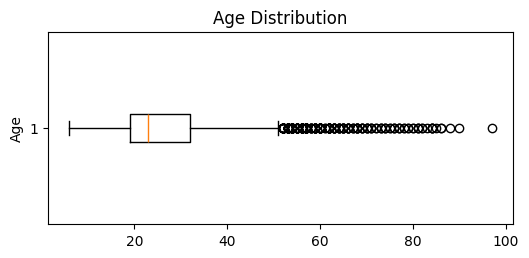

In [9]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['age'], vert = False)
plt.title('Age Distribution')
plt.ylabel('Age')
plt.show()

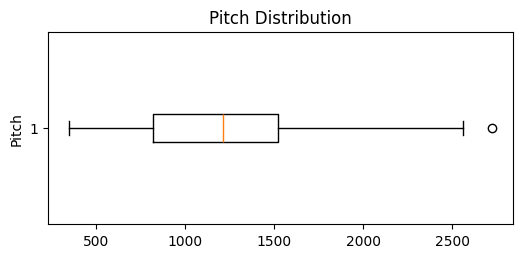

In [10]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['mean_pitch'], vert = False)
plt.title('Pitch Distribution')
plt.ylabel('Pitch')
plt.show()

We can try to remove the outlier detected by the *mean_pitch*.

In [11]:
Q1 = df['mean_pitch'].quantile(0.25)
Q3 = df['mean_pitch'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['mean_pitch'] >= (Q1 - 1.5 * IQR)) & (df['mean_pitch'] <= (Q3 + 1.5 * IQR))]
df.shape

(2932, 21)

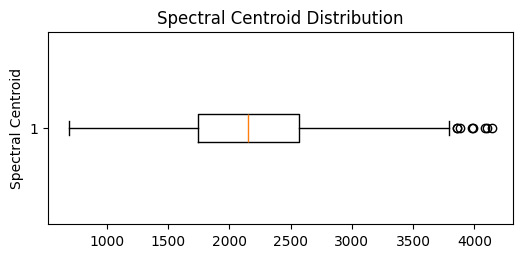

In [12]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['spectral_centroid_mean'], vert = False)
plt.title('Spectral Centroid Distribution')
plt.ylabel('Spectral Centroid')
plt.show()

We can try to remove the outlier detected by the *spectral_centroid*.

In [13]:
Q1 = df['spectral_centroid_mean'].quantile(0.25)
Q3 = df['spectral_centroid_mean'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['spectral_centroid_mean'] >= (Q1 - 1.5 * IQR)) & (df['spectral_centroid_mean'] <= (Q3 + 1.5 * IQR))]
df.shape

(2924, 21)

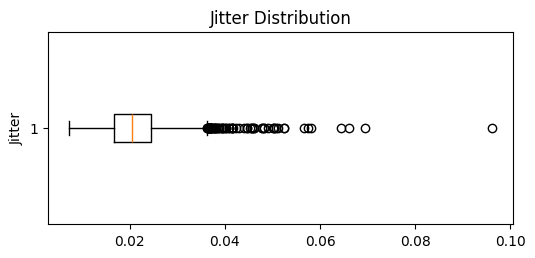

In [14]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['jitter'], vert = False)
plt.title('Jitter Distribution')
plt.ylabel('Jitter')
plt.show()

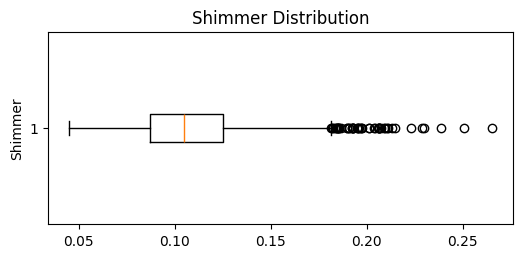

In [15]:
plt.figure(figsize=(6, 2.5))
plt.boxplot(dev_df['shimmer'], vert = False)
plt.title('Shimmer Distribution')
plt.ylabel('Shimmer')
plt.show()

## 2.2 Correlation between features

In [16]:
spearman_corr = dev_df['num_words'].corr(dev_df['num_characters'], method='spearman')
print(f"Spearman's rank correlation: {spearman_corr}")

Spearman's rank correlation: 0.9950099134407278


In [17]:
spearman_corr = dev_df['num_pauses'].corr(dev_df['silence_duration'], method='spearman')
print(f"Spearman's rank correlation: {spearman_corr}")

Spearman's rank correlation: 0.7378261155278655


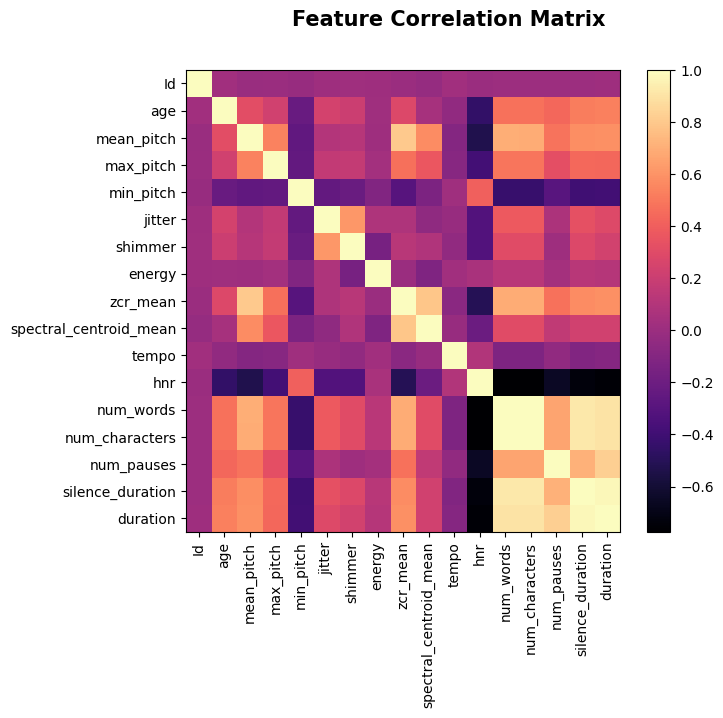

In [18]:
# Plot correlation Matrix
corr = df.drop(columns=['ethnicity','path','gender', 'sampling_rate']).corr()

plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap='magma', interpolation='none', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation='vertical')
plt.yticks(range(len(corr)), corr.columns);
plt.suptitle('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.show()

We can see that *num_words* and *num_characters* are very higly correlated. We decide to remove *num_characters* from the dataset. The same holds for *num_pauses* and *silence_duration* and we decided to keep *silence_duration*. 

In [19]:
df = df.drop(columns=['num_pauses', 'num_characters'], axis=1)
eval_df = eval_df.drop(columns=['num_pauses', 'num_characters'], axis=1)

# 3 Data Preprocessing

## 3.1 Numerical features
We can perform normalization on the data do improve in the RMSE

In [20]:
from sklearn.preprocessing import StandardScaler

num_feat = df.select_dtypes(include=['float64', 'int64']).columns
num_feat = num_feat.drop('age')
scaler = StandardScaler()
df[num_feat] = scaler.fit_transform(df[num_feat])
eval_df[num_feat] = scaler.transform(eval_df[num_feat])

## 3.2 Categorical features

### 3.2.1 One-Hot Encoding - Gender

In [21]:
dev_df['gender'].unique().size, dev_df['ethnicity'].unique().size

(2, 165)

### 3.2.2 Feature Reduction - Ethnicity

The cardinality of _ethinicity_ is too high to perform 1he, so we perform it on _gender_. Instead, on the ethnicity we can proceed with three possible approaches
- All ethnicities: __eth_group__ = False and __eth__ = True
- Ethnicities grouped: __eth_group__ = True
- No Ethnicities included: __eth_group__ = False and __eth__ = False

By grouping the ethnicities together we aggregate the ethnicity to a higher hierarchical level providing better stability and has less variability. We chose 5 supergroups:
- Indo-European
- Afro-Asiatic
- Sino-Tibetan
- Austroasiatic & Pacific
- Other

Such groups contain ethnicities with similar phonetic characteristics.

In [22]:
eth_group = True
eth = True

We can group ethnicities into broader ethnical categories based on voice and phonetic similarities.

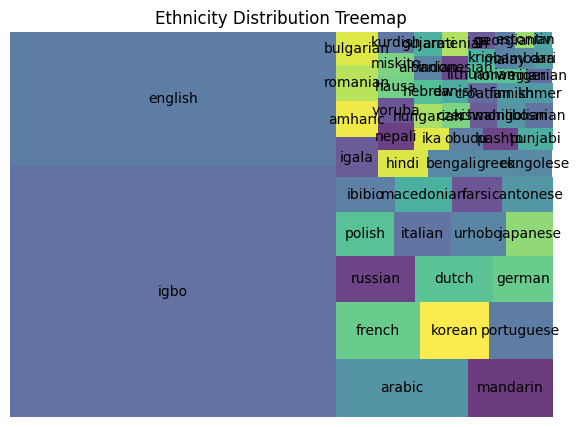

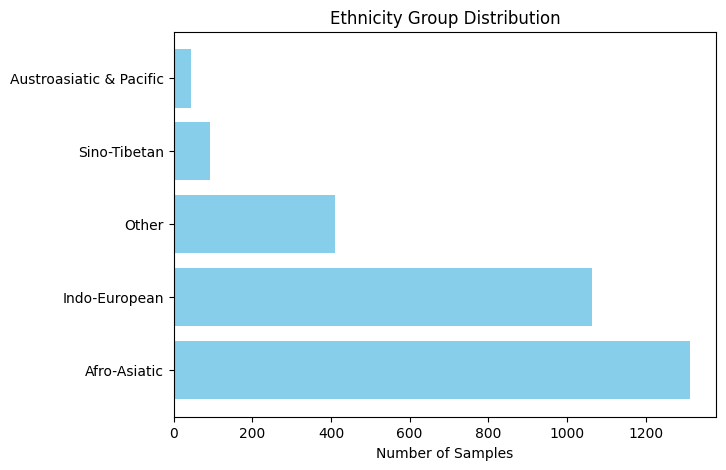

In [23]:
import squarify

if eth_group:
    # Treemap of the 60 most common ethnicities

    # Calculate the percentage of samples for each ethnicity
    ethnicity_counts = dev_df['ethnicity'].value_counts()
    ethnicity_percentage = (ethnicity_counts / ethnicity_counts.sum()) * 100
    # Prepare data for treemap
    sizes = ethnicity_percentage.values
    labels = ethnicity_percentage.index

    # Plot the treemap
    plt.figure(figsize=(7, 5))
    squarify.plot(sizes=sizes[:60], label=labels[:60], alpha=0.8)
    plt.title('Ethnicity Distribution Treemap')
    plt.axis('off')
    plt.show()
    # Define grouped ethnicities
    ethnicity_groups = {
        "Indo-European": [
            "english", "german", "dutch", "french", "italian", "spanish", "portuguese",
            "russian", "polish", "croatian", "icelandic", "armenian", "hindi", "bengali",
            "bosnian", "azerbaijani", "romanian", "albanian", "macedonian", "irish",
            "greek", "latvian", "lithuanian", "kazakh", "maltese", "finnish",
            "norwegian", "swedish", "danish", "estonian", "luxembourgeois", "faroese",
            "sardinian", "bavarian", "basque"
        ],
        "Afro-Asiatic": [
            "arabic", "hebrew", "amharic", "hausa", "coptic", "amazigh", "kabyle",
            "ethiopian", "akan", "yoruba", "igbo", "edo", "oromo", "kanuri", "fulani",
            "mandinka", "tiv", "bambara", "garifuna", "mende", "lingala", "rundi",
            "swahili", "kikuyu", "luo", "zulu", "xhosa", "bafang", "bamun", "ibibio",
            "mankanya", "ikwerre", "nigerian", "cameroonian", "ijaw", "annang", "fang",
            "ngemba"
        ],
        "Sino-Tibetan": [
            "mandarin", "cantonese", "gan", "hakka", "hainanese", "burmese", "tibetan",
            "chinese"
        ],
        "Austroasiatic & Pacific": [
            "filipino", "indonesian", "malay", "cebuano", "papiamentu", "hmong",
            "khmer", "lao", "vietnamese", "rotuman", "mauritian", "fijian", "pohnpeian", 
            "carolinian", "kiribati", "satawalese","lamotrekese", "mortlockese", "chamorro"
        ],
        "Other": [
            "unknown", "obudu", "ashanti", "kalanga", "nandi", "moba", "sarua",
            "kaire-kaire", "gedeo", "lamaholot", "dinka", "turkish", "kazakh", "kirghiz",
            "finnish", "hungarian", "estonian", "tamil", "telugu", "kannada", "malayalam"
        ]
    }

    # Function to map ethnicities to their corresponding group
    def map_ethnicity(ethnicity):
        for group, ethnicities in ethnicity_groups.items():
            if ethnicity.lower() in ethnicities:
                return group
        return "Other"  # For rare cases not in mapping

    # Apply function to create new column
    df["ethnicity_group"] = df["ethnicity"].apply(map_ethnicity)
    eval_df["ethnicity_group"] = eval_df["ethnicity"].apply(map_ethnicity)

    plt.figure(figsize=(7, 5))
    plt.barh(df['ethnicity_group'].value_counts().index, df['ethnicity_group'].value_counts(), color='skyblue')
    plt.title('Ethnicity Group Distribution')
    plt.xlabel('Number of Samples')
    plt.show()
    encoded_df = pd.get_dummies(df, columns=['gender', 'ethnicity_group'])
    eval_df = pd.get_dummies(eval_df, columns=['gender', 'ethnicity_group'])
    # Ensure eval_df has the same dummy columns as encoded_df
    for col in encoded_df.columns:
        if col not in eval_df.columns:
            eval_df[col] = 0
    eval_df = eval_df[encoded_df.columns].drop(columns=["age"])
    
else:
    if eth:
        encoded_df = pd.get_dummies(df, columns=['gender', 'ethnicity'])
        eval_df = pd.get_dummies(eval_df, columns=['gender', 'ethnicity'])
        # Ensure eval_df has the same dummy columns as encoded_df
        for col in encoded_df.columns:
            if col not in eval_df.columns:
                eval_df[col] = 0
        eval_df = eval_df[encoded_df.columns].drop(columns=["age"])
    else:
        encoded_df = pd.get_dummies(df, columns=['gender'])
        eval_df = pd.get_dummies(eval_df, columns=['gender'])

Now we perform Dummy encoding on the __ethnicity_group__ feature

## 3.3 Feature Selection

We try to perform iterative feature selection using a Random Forest Regressor with default hyperparamters.

In [24]:
df_dropped = encoded_df.drop(columns=['path', 'Id', 'ethnicity']) # drop non-numeric columns 'ethnicity'
feature_names = df_dropped.drop(columns=["age"]).columns
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, root_mean_squared_error
reg = MLPRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
rmse = root_mean_squared_error(y_valid, y_pred)
print(f"R^2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2 Score: 0.4078
RMSE: 10.3606


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


We use the Lasso regressor to perform regularization and feature reduction

In [26]:
from sklearn.linear_model import Ridge
reg = Ridge(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)

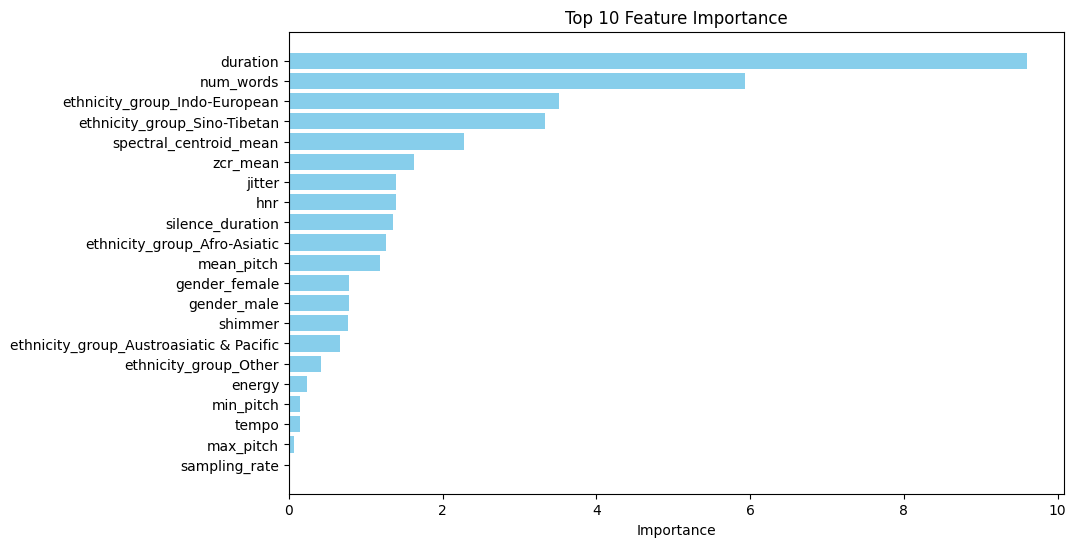

In [27]:
# Use the Ridge model to get feature importances
ndx = np.argsort(np.abs(reg.coef_))
features_df = pd.DataFrame(sorted(zip(feature_names[ndx], np.abs(reg.coef_)[ndx]), key=lambda x: x[1], reverse=False), columns=['Feature', 'Importance'])

plt.figure(figsize=(10, 6))
plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance')
plt.show()

Try to remove also *sampling_rate*, *num_words* and the *gender*.

In [28]:
col_drop = features_df[features_df['Importance'] < 0.2]['Feature']
print(f"Columns to drop: {col_drop}")
df_dropped = df_dropped.drop(columns=col_drop) # drop non-numeric columns
feature_names = df_dropped.drop(columns=["age"]).columns
X = df_dropped.drop(columns=["age"])
y = df_dropped["age"]
X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)

Columns to drop: 0    sampling_rate
1        max_pitch
2            tempo
3        min_pitch
Name: Feature, dtype: object


In [29]:
reg = MLPRegressor(random_state=42)
reg.fit(X_train, y_train)
y_pred = reg.predict(X_valid)
r2 = r2_score(y_valid, y_pred)
rmse = root_mean_squared_error(y_valid, y_pred)
print(f"R^2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2 Score: 0.3973
RMSE: 10.5263


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Try to summarize pitch range.

In [30]:
#df_dropped['pitch_range'] = df_dropped['max_pitch'] - df_dropped['min_pitch']

In [31]:
#spearman_corr = df_dropped['pitch_range'].corr(df_dropped['jitter'], method='spearman')
#print(f"Spearman's rank correlation: {spearman_corr}")

In [32]:
#feature_names = df_dropped.drop(columns=["age"]).columns
#X = df_dropped.drop(columns=["age"])
#y = df_dropped["age"]
#X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)

In [33]:
#reg = MLPRegressor(random_state=42)
#reg.fit(X_train, y_train)
#y_pred = reg.predict(X_valid)
#r2 = r2_score(y_valid, y_pred)
#rmse = root_mean_squared_error(y_valid, y_pred)
#print(f"R^2 Score: {r2:.4f}")
#print(f"RMSE: {rmse:.4f}")

Doesn't seem to improve on the performance:
R^2 Score: 0.3353
RMSE: 11.0537

In [34]:
#df_dropped['voice_silence_ratio'] = (df_dropped['duration'] - df_dropped['silence_duration'])/ df_dropped['silence_duration']
#df_dropped['voice_silence_ratio'] = scaler.fit_transform(df_dropped[['voice_silence_ratio']])

In [35]:
#feature_names = df_dropped.drop(columns=["age"]).columns
#X = df_dropped.drop(columns=["age", 'duration', 'silence_duration'])
#y = df_dropped["age"]
#X_train, X_valid, y_train, y_valid = train_test_split(X,y, shuffle=True, random_state=42)

In [36]:
#reg = MLPRegressor(random_state=42)
#reg.fit(X_train, y_train)
#y_pred = reg.predict(X_valid)
#r2 = r2_score(y_valid, y_pred)
#rmse = root_mean_squared_error(y_valid, y_pred)
#print(f"R^2 Score: {r2:.4f}")
#print(f"RMSE: {rmse:.4f}")

In [37]:
print(eval_df.columns)

Index(['Id', 'sampling_rate', 'ethnicity', 'mean_pitch', 'max_pitch',
       'min_pitch', 'jitter', 'shimmer', 'energy', 'zcr_mean',
       'spectral_centroid_mean', 'tempo', 'hnr', 'num_words',
       'silence_duration', 'path', 'duration', 'gender_female', 'gender_male',
       'ethnicity_group_Afro-Asiatic',
       'ethnicity_group_Austroasiatic & Pacific',
       'ethnicity_group_Indo-European', 'ethnicity_group_Other',
       'ethnicity_group_Sino-Tibetan'],
      dtype='object')


In [38]:
eval_df.set_index('Id', inplace=True)
eval_df = eval_df.drop(columns=['path', 'ethnicity'])
eval_df = eval_df.drop(columns=col_drop)

In [39]:
dev_df = df_dropped.copy()

# 4 Model Selection

# 5 Hyperparameter Tuning

# 6 Evaluation

In [40]:
# make predictions
reg = MLPRegressor(random_state=42)
X = dev_df.drop(columns=["age"])
y = dev_df["age"]
reg.fit(X, y)
y_pred = reg.predict(eval_df)

with open('TESTS/predictions_Std_EthGroup.csv', 'w') as f:
    f.write("Id,Predicted\n")
    for i, val in enumerate(y_pred):
        f.write(f"{i},{val}\n")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Results obtained on the leaderboard
- __MLP STANDARD + ETH GROUPS: 9.822__
- MLP STANDARD + ETH: 9.994
- MLP MINMAX SCALER: 10.165
- MLPREGRESSOR BASELINE: 10.228